# 📊 Students' Adaptability Level in Online Education
## Phase 3 – Feature Engineering
### 🛠 Import Required Libraries

In this section we import libraries required for feature engineering, machine learning models, clustering, and feature importance analysis.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.cluster import KMeans

import lightgbm as lgb

import shap

import warnings
warnings.filterwarnings('ignore')

## 📁 Load Preprocessed Dataset

The dataset processed in Phase 2 is loaded. This dataset already contains encoded categorical variables and balanced classes using SMOTE.

In [2]:
df = pd.read_csv('/kaggle/input/notebooks/zohawaqas10/ml-project/preprocessed_students_adaptability.csv')

df.head()

,Gender,Age,Education Level,Institution Type,IT Student,Location,Load-shedding,Financial Condition,Internet Type,Network Type,Class Duration,Self Lms,Device,Adaptivity Level
0,0,3,2,1,0,1,1,0,1,2,2,0,2,2
1,1,3,2,1,0,1,0,0,0,2,1,1,1,2
2,1,2,0,0,0,1,1,0,1,2,1,0,1,2
3,1,1,1,1,0,1,1,0,0,2,1,0,1,2
4,1,2,1,1,0,1,1,1,0,1,0,0,1,1


The dataset has been successfully loaded. The preview above shows the first few rows of the dataset, allowing us to verify that the data has been imported correctly.

## 🎯 Separating Features and Target Variable

In order to train machine learning models, the dataset is divided into input features (X) and the target variable (y). The target variable in this dataset is **Adaptivity Level**, which represents the adaptability of students to online education.

In [3]:
X = df.drop("Adaptivity Level", axis=1)
y = df["Adaptivity Level"]

The dataset has now been divided into features (X) and target variable (y). This separation is necessary for performing feature importance analysis and training machine learning models.

### 🌲 Feature Importance using Random Forest

Random Forest is a tree-based algorithm that provides feature importance scores based on how much each feature reduces impurity in the decision trees.

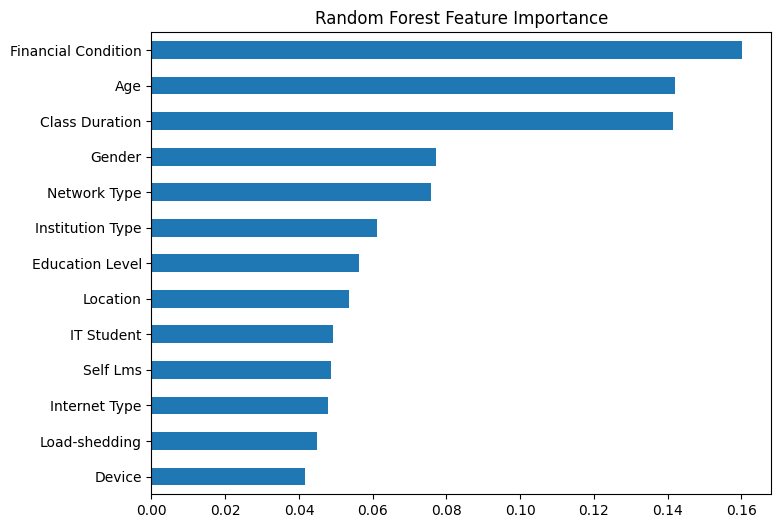

In [4]:
rf = RandomForestClassifier()

rf.fit(X,y)

importances = rf.feature_importances_

rf_importance = pd.Series(importances, index=X.columns)

rf_importance.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Random Forest Feature Importance")
plt.show()

The visualization above shows how important each feature is according to the Random Forest model. Features with higher importance scores contribute more to predicting students’ adaptability levels.

## 🌳 Feature Importance using Decision Tree

Decision Trees provide feature importance by measuring how each feature improves the purity of the nodes during tree construction.

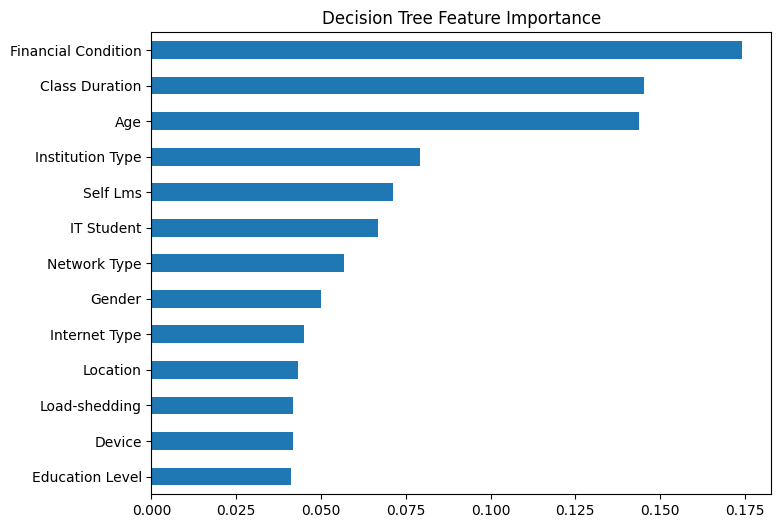

In [5]:
dt = DecisionTreeClassifier()

dt.fit(X, y)

dt_importance = pd.Series(dt.feature_importances_, index=X.columns)

dt_importance.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Decision Tree Feature Importance")
plt.show()

The decision tree importance scores highlight which variables contribute most to splitting the data effectively and predicting adaptability levels.

## 📈 Feature Importance using Logistic Regression

Logistic Regression estimates coefficients for each feature. The magnitude of these coefficients indicates the influence of each feature on the prediction outcome.

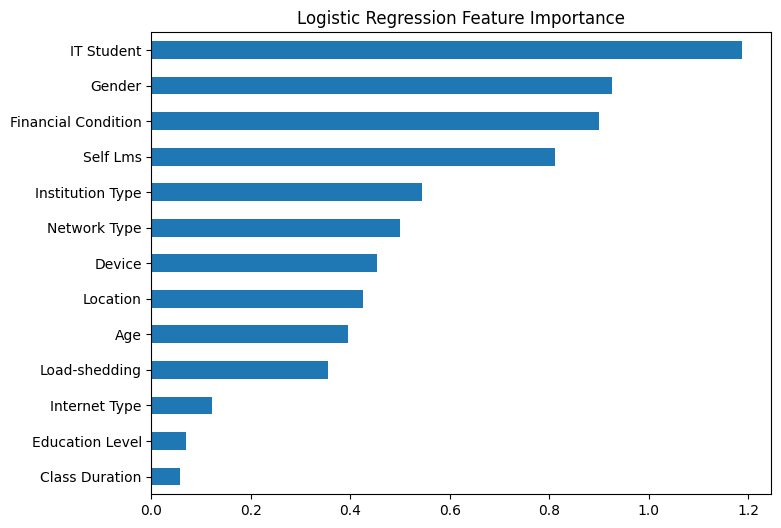

In [6]:
lr = LogisticRegression(max_iter=200)

lr.fit(X, y)

importance = np.abs(lr.coef_[0])

lr_importance = pd.Series(importance, index=X.columns)

lr_importance.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("Logistic Regression Feature Importance")
plt.show()

The plot shows the relative influence of features based on logistic regression coefficients. Larger coefficient values indicate stronger influence on the prediction.

## ⚙️ Feature Importance using Support Vector Machine

Support Vector Machine with a linear kernel provides coefficients that represent the importance of features in determining the decision boundary.

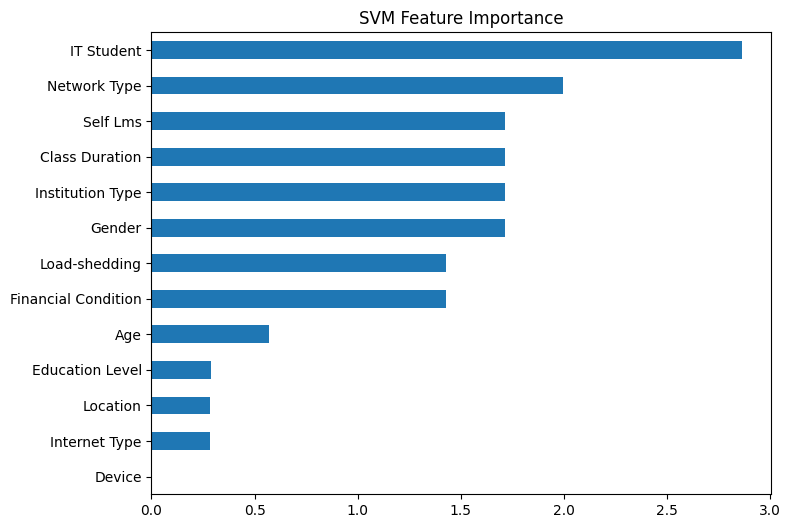

In [7]:
svm = SVC(kernel='linear')

svm.fit(X, y)

importance = np.abs(svm.coef_[0])

svm_importance = pd.Series(importance, index=X.columns)

svm_importance.sort_values().plot(kind='barh', figsize=(8,6))

plt.title("SVM Feature Importance")
plt.show()

The SVM feature importance plot helps identify which variables have stronger influence on the classification boundary.

## 📊 Naive Bayes Model

Naive Bayes is trained as an additional algorithm to understand how the dataset behaves with probabilistic classification methods.

In [8]:
nb = GaussianNB()

nb.fit(X, y)

print("Naive Bayes Model Trained Successfully")

Naive Bayes Model Trained Successfully


The Naive Bayes model has been trained successfully. Although Naive Bayes does not directly provide feature importance scores, it helps evaluate how probabilistic models perform on this dataset.

## 🔍 Feature Importance using SHAP

SHAP (SHapley Additive exPlanations) is used to interpret machine learning models. It provides a detailed explanation of how each feature contributes to the model's predictions.

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001242 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 35
[LightGBM] [Info] Number of data points in the train set: 1875, number of used features: 13
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


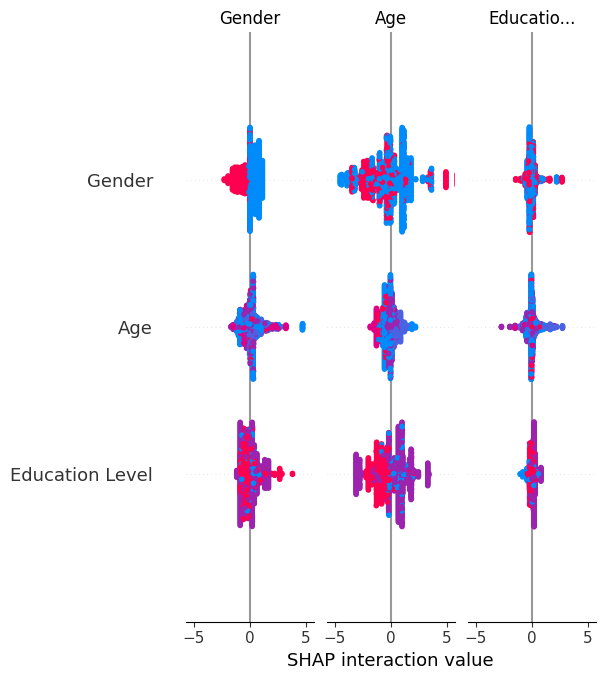

In [9]:
model = lgb.LGBMClassifier()

model.fit(X, y)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

The SHAP summary plot illustrates the contribution of each feature toward the model predictions. Features appearing at the top of the plot are considered the most influential.

## 🧩 Creating New Features

Feature engineering is performed to generate new meaningful variables from the existing dataset. These features represent combinations of demographic, technological, and socio-economic factors that may influence adaptability to online education.

In [10]:
df["tech_access_score"] = df["Device"] + df["Internet Type"] + df["Network Type"]

df["infra_difficulty"] = df["Load-shedding"] + df["Location"]

df["socioeconomic_score"] = df["Financial Condition"] + df["Institution Type"]

Three new features were created:

• **tech_access_score** – represents students’ access to technology and internet connectivity.  
• **infra_difficulty** – represents infrastructure challenges such as electricity issues and geographical location.  
• **socioeconomic_score** – represents socio-economic background and institutional support.

These features help capture more complex relationships between variables.

## ⚡ Evaluating New Features using LightGBM

LightGBM is used to quickly evaluate the predictive performance of the dataset after creating new features.

In [11]:
X = df.drop("Adaptivity Level", axis=1)
y = df["Adaptivity Level"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

model = lgb.LGBMClassifier()

model.fit(X_train,y_train)

print("Accuracy:", model.score(X_test,y_test))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000247 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 48
[LightGBM] [Info] Number of data points in the train set: 1500, number of used features: 16
[LightGBM] [Info] Start training from score -1.092630
[LightGBM] [Info] Start training from score -1.100614
[LightGBM] [Info] Start training from score -1.102620
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further s

The LightGBM model was trained to evaluate the effectiveness of the engineered features. The accuracy score indicates how well the dataset predicts students’ adaptability levels.

## 📏 Feature Standardization

Standardization is applied to ensure all features are on a similar scale. This improves the performance of algorithms that are sensitive to feature magnitude.

In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

The dataset features have been standardized so that they have a mean of 0 and a standard deviation of 1.

## 🔵 Creating Cluster Feature using K-Means

K-Means clustering is applied to group students with similar characteristics. The cluster label is added as a new feature to the dataset.

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42)

df["student_cluster"] = kmeans.fit_predict(X_scaled)

The K-Means algorithm grouped students into clusters based on similarities in their characteristics. The cluster label can help capture hidden patterns in the dataset.

## 💾 Saving Final Dataset

After completing feature engineering, the dataset is saved so it can be directly used in the next phase for training and evaluating machine learning models.

In [14]:
df.to_csv("feature_engineered_students_dataset.csv", index=False)

The final dataset has been saved successfully and will be used in the next phase of the project.